## Practice session of vision finetuning model

In [15]:
from fastai.vision.all import *

In [16]:
path=untar_data(URLs.PETS)
path.ls()

[Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/.DS_Store'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/models'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/annotations')]

In [17]:
files = get_image_files(path/"images")
def label_func(f): return f[0].isupper()
dls = ImageDataLoaders.from_name_func(path, files, label_func,item_tfms=Resize(224),shuffle=True, bs=64)
print(len(files))

7391


<div></div>

epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.219111,0.052140,0.017591,0.982409,00:32


epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.051990,0.031240,0.011502,0.988498,00:39


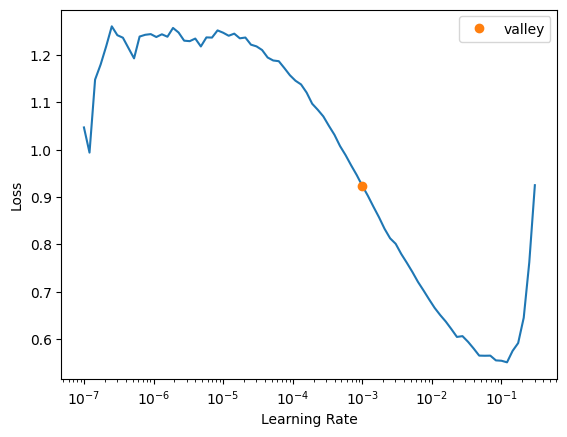

In [5]:
learn = vision_learner(dls, resnet18, metrics=[error_rate, accuracy])
lrs = learn.lr_find(suggest_funcs=(valley))
learn.fine_tune(1, lrs.valley)

## Understanding overfitting and increasing looses it

### Increasing losses - leads to brain dead

In [6]:
learn = vision_learner(dls, resnet18, metrics=[error_rate, accuracy])
learn.fine_tune(1, base_lr=15)

epoch,train_loss,valid_loss,error_rate,accuracy,time
0,5306.075684,167328.218750,0.319350,0.680650,00:32


epoch,train_loss,valid_loss,error_rate,accuracy,time
0,742.397217,564.509644,0.566306,0.433694,00:39


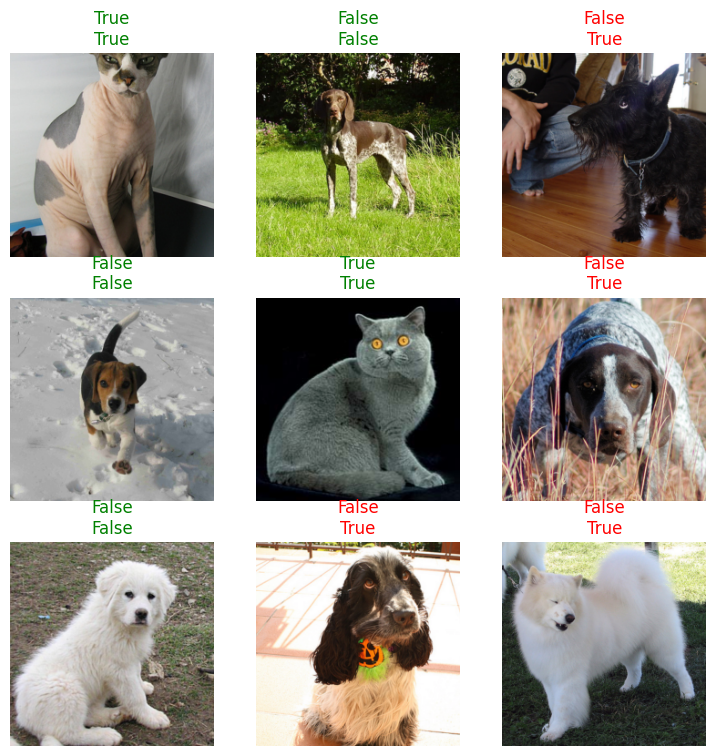

In [7]:
learn.show_results()

In [8]:
learn.get_preds()

(tensor([[0.0000e+00, 1.0000e+00],
         [9.6409e-43, 1.0000e+00],
         [0.0000e+00, 1.0000e+00],
         ...,
         [0.0000e+00, 1.0000e+00],
         [0.0000e+00, 1.0000e+00],
         [0.0000e+00, 1.0000e+00]]),
 tensor([0, 0, 0,  ..., 1, 0, 0]))

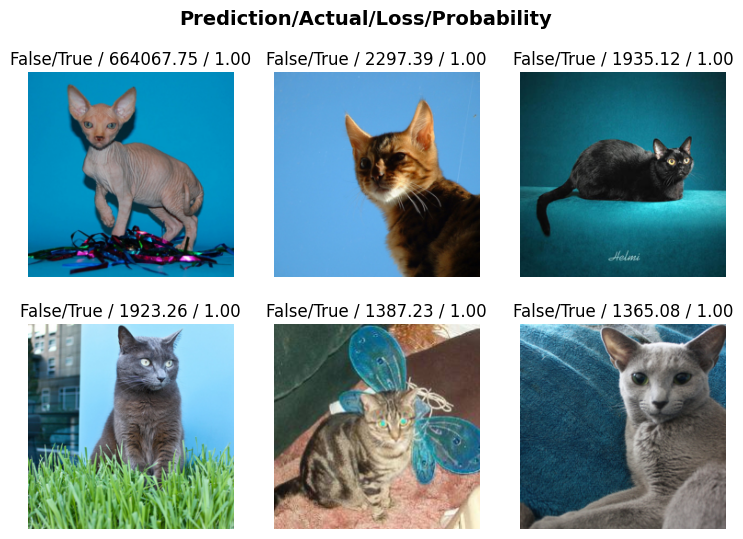

In [9]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_top_losses(k=6)

<div></div>

epoch,train_loss,valid_loss,error_rate,accuracy,time
0,277.735046,4468.456543,0.352503,0.647497,00:32


epoch,train_loss,valid_loss,error_rate,accuracy,time
0,264.029144,485.996704,0.336942,0.663058,00:39


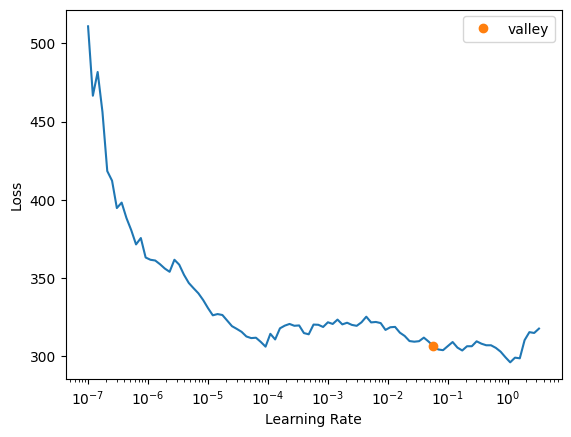

In [10]:
lrs = learn.lr_find(suggest_funcs=(valley))
learn.fine_tune(1)

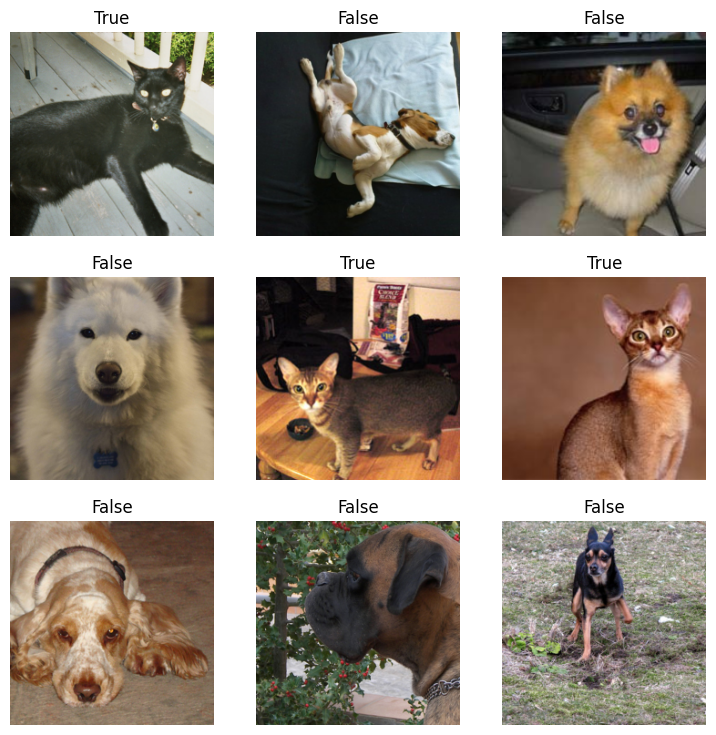

In [11]:
dls.show_batch()

<div></div>

SuggestedLRs(valley=0.0004786300996784121)

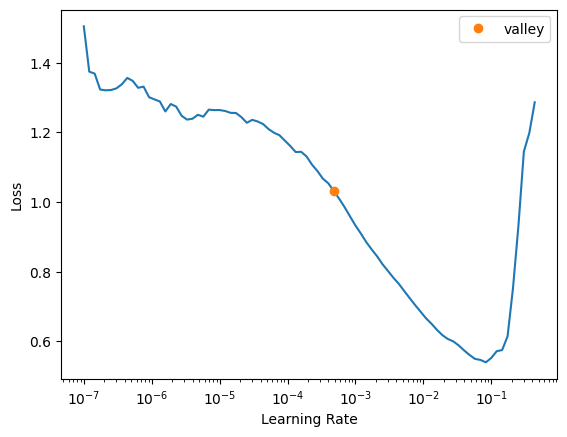

In [15]:
learner = vision_learner(dls, resnet18, metrics=[error_rate, accuracy])
learner.lr_find()

In [17]:
learner.fine_tune(1, 4.7e-4)

epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.254283,0.053127,0.018268,0.981732,00:32


epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.071681,0.032649,0.012855,0.987145,00:39


In [18]:
learner.get_preds()

(tensor([[9.9996e-01, 4.3057e-05],
         [9.9998e-01, 1.7951e-05],
         [2.8090e-01, 7.1910e-01],
         ...,
         [1.9329e-04, 9.9981e-01],
         [9.2691e-01, 7.3090e-02],
         [9.9803e-01, 1.9691e-03]]),
 tensor([0, 0, 0,  ..., 1, 0, 0]))

In [19]:
learner.summary()

<div></div>

Sequential (Input shape: 64 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 64 x 112 x 112 
Conv2d                                    9408       True      
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     64 x 64 x 56 x 56   
MaxPool2d                                                      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                      

### Trying different models using TIMM

In [8]:
!pip install timm
import timm



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [20]:
timm.list_models("convnext*")

['convnext_atto',
 'convnext_atto_ols',
 'convnext_atto_rms',
 'convnext_base',
 'convnext_femto',
 'convnext_femto_ols',
 'convnext_large',
 'convnext_large_mlp',
 'convnext_nano',
 'convnext_nano_ols',
 'convnext_pico',
 'convnext_pico_ols',
 'convnext_small',
 'convnext_tiny',
 'convnext_tiny_hnf',
 'convnext_xlarge',
 'convnext_xxlarge',
 'convnext_zepto_rms',
 'convnext_zepto_rms_ols',
 'convnextv2_atto',
 'convnextv2_base',
 'convnextv2_femto',
 'convnextv2_huge',
 'convnextv2_large',
 'convnextv2_nano',
 'convnextv2_pico',
 'convnextv2_small',
 'convnextv2_tiny']

<div></div>

epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.180361,0.007878,0.001353,0.998647,00:56


epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.022671,0.005112,0.002030,0.997970,01:48


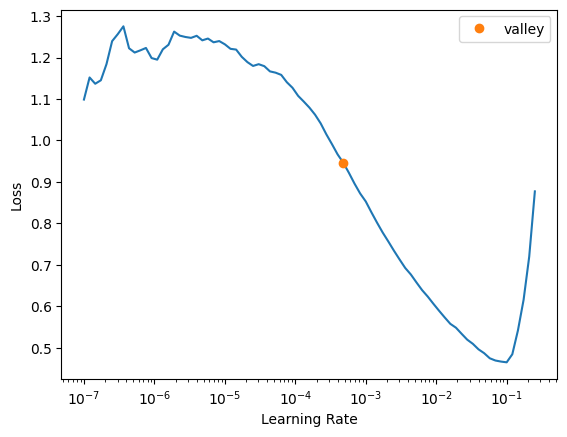

In [25]:
learner = vision_learner(dls, "convnext_nano", metrics=[error_rate, accuracy])
lrs = learner.lr_find(suggest_funcs=(valley))
learner.fine_tune(1,lrs.valley)

In [41]:
img = PILImage.create("cat-test.jpeg")
img.to_thumb(192)

pred, pred_idx, probs = learner.predict(img)

print(f"Prediction: {pred}")
print(f"Probability: {probs[pred_idx]:.4f}")

Prediction: True
Probability: 1.0000


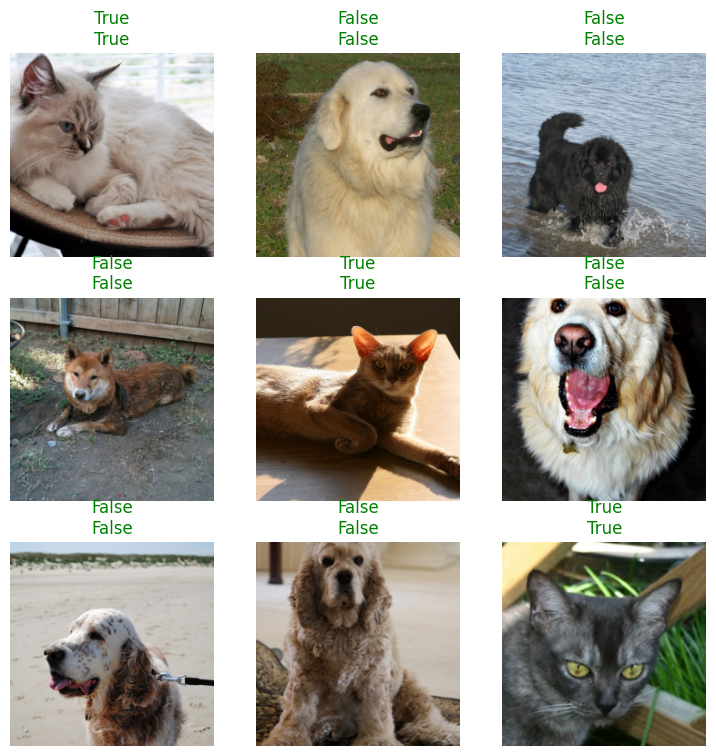

In [48]:
learner.show_results(max_n=9)